# 02 — Baseline model & first submission

Reproduce el benchmark oficial (persistencia + HistGradientBoostingRegressor, `src/model.py`) sobre un split cronoógico, muestra diagnósticos de regresión/dataviz, y genera `outputs/submission.csv` listo para subir a Zindi.

Todo el código del pipeline vive en `src/` (ya validado, ver `RESOURCES.md`); este notebook solo lo invoca y añade visualización.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, data, evaluate, features, model
from src.train import get_feature_cols



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\alher\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\alher\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\alher\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\alher\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\alher\anaconda3\Lib\site-pac

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\alher\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\alher\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\alher\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\alher\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\alher\anaconda3\Lib\site-pac

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



## Carga de datos

In [2]:
train, test, sample_submission = data.load_raw_data()
feature_cols = get_feature_cols(train)
print("Feature columns:", feature_cols)
print("train:", train.shape, "| test:", test.shape)


Feature columns: ['TWS_t', 'month_sin', 'month_cos', 'SPEI_01_t', 'SPEI_03_t', 'SPEI_06_t', 'SPEI_12_t', 'SOIL_MOISTURE_t']
train: (2154021, 13) | test: (280961, 13)


## Split cronoógico train/validación

Sin shuffle: es una tarea de forecasting, un split aleatorio filtraría información futura entre filas cercanas en tiempo/espacio (`src/evaluate.py::time_train_val_split`).

In [3]:
fit_df, val_df = evaluate.time_train_val_split(train)
print(f"Fit: {fit_df[config.TIME_COL].min()} -> {fit_df[config.TIME_COL].max()} ({len(fit_df)} filas)")
print(f"Val: {val_df[config.TIME_COL].min()} -> {val_df[config.TIME_COL].max()} ({len(val_df)} filas)")


Fit: 2002-05-01 00:00:00 -> 2012-03-01 00:00:00 (1716994 filas)
Val: 2012-04-01 00:00:00 -> 2015-08-01 00:00:00 (437027 filas)


## Entrenar el modelo baseline

In [4]:
X_fit = features.select_base_features(fit_df, feature_cols)
y_fit = fit_df[config.TARGET_COL].to_numpy()
X_val = features.select_base_features(val_df, feature_cols)
y_val = val_df[config.TARGET_COL].to_numpy()

baseline_model = model.make_baseline_model()
baseline_model.fit(X_fit, y_fit)

y_val_pred = model.predict(baseline_model, X_val)
y_val_persist = model.make_persistence_prediction(val_df)


C:\Users\alher\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\alher\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\alher\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\alher\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\alher\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _wina

## Métricas: modelo vs. persistencia

In [5]:
metrics_df = pd.DataFrame({
    "model": evaluate.compute_metrics(y_val, y_val_pred),
    "persistence": evaluate.compute_metrics(y_val, y_val_persist),
}).T
metrics_df["rmse_improvement_vs_persistence"] = (
    metrics_df.loc["persistence", "rmse"] - metrics_df["rmse"]
)
metrics_df


,rmse,mae,r2,rmse_improvement_vs_persistence
model,0.607264,0.428698,0.460179,0.054816
persistence,0.662081,0.455159,0.358324,0.000000


## Diagnóstico: predicción vs. verdad

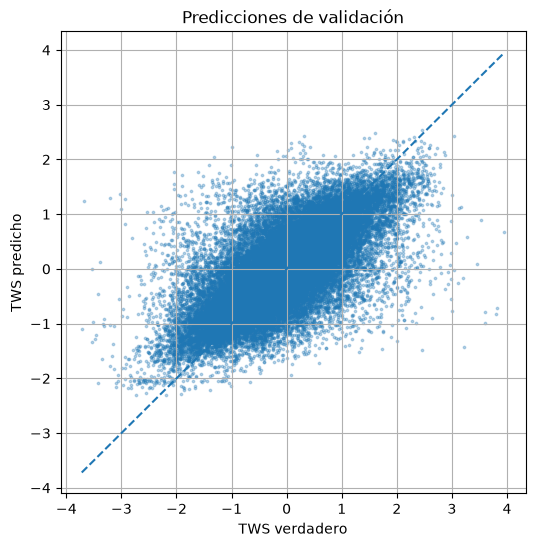

In [6]:
rng = np.random.RandomState(config.RANDOM_STATE)
idx = rng.choice(len(y_val), size=min(50000, len(y_val)), replace=False)

plt.figure(figsize=(6, 6))
plt.scatter(y_val[idx], y_val_pred[idx], s=3, alpha=0.3)
mn = min(y_val[idx].min(), y_val_pred[idx].min())
mx = max(y_val[idx].max(), y_val_pred[idx].max())
plt.plot([mn, mx], [mn, mx], "--")
plt.xlabel("TWS verdadero"); plt.ylabel("TWS predicho")
plt.title("Predicciones de validación")
plt.grid(True)
plt.show()


## Mapa de error espacial (GIS)

Un mes de validación: TWS verdadero, predicho, y error (pred − verdad).

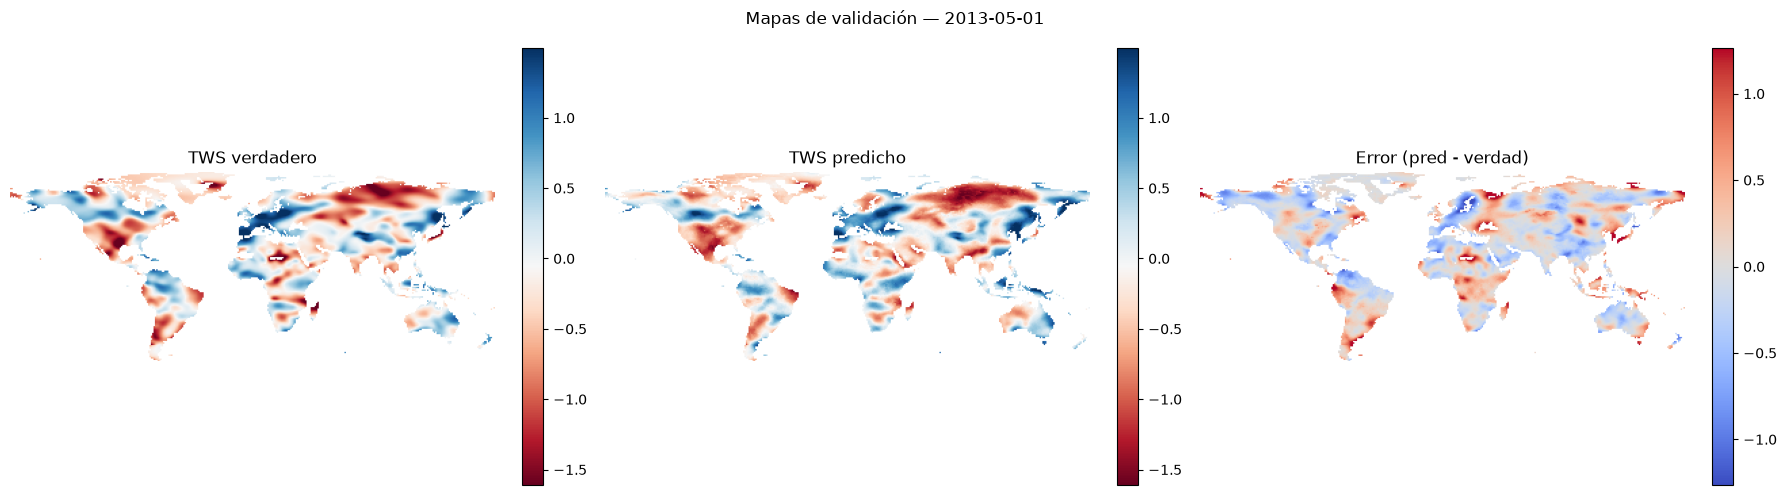

In [7]:
def plot_error_map(df, y_true, y_pred, time_value):
    mask = (df[config.TIME_COL] == time_value).to_numpy()
    sub = df.loc[mask, [config.LAT_COL, config.LON_COL]].reset_index(drop=True)
    yt, yp = np.asarray(y_true)[mask], np.asarray(y_pred)[mask]

    lats = np.sort(sub[config.LAT_COL].unique())
    lons = np.sort(sub[config.LON_COL].unique())
    lat_idx = {v: i for i, v in enumerate(lats)}
    lon_idx = {v: i for i, v in enumerate(lons)}

    true_grid = np.full((len(lats), len(lons)), np.nan)
    pred_grid = np.full((len(lats), len(lons)), np.nan)
    for i, row in sub.iterrows():
        r, c = lat_idx[row[config.LAT_COL]], lon_idx[row[config.LON_COL]]
        true_grid[r, c] = yt[i]
        pred_grid[r, c] = yp[i]
    error_grid = pred_grid - true_grid

    vmin, vmax = np.nanpercentile(yt, 1), np.nanpercentile(yt, 99)
    emax = np.nanpercentile(np.abs(error_grid[np.isfinite(error_grid)]), 99)

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    for ax, grid, title, cmap, vm in [
        (axs[0], true_grid, "TWS verdadero", "RdBu", (vmin, vmax)),
        (axs[1], pred_grid, "TWS predicho", "RdBu", (vmin, vmax)),
        (axs[2], error_grid, "Error (pred - verdad)", "coolwarm", (-emax, emax)),
    ]:
        im = ax.imshow(grid, cmap=cmap, vmin=vm[0], vmax=vm[1], origin="lower")
        ax.set_title(title); ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046)
    plt.suptitle(f"Mapas de validación — {pd.Timestamp(time_value).strftime('%Y-%m-%d')}")
    plt.tight_layout()
    plt.show()


val_times = np.sort(val_df[config.TIME_COL].unique())
plot_error_map(val_df, y_val, y_val_pred, val_times[min(7, len(val_times) - 1)])


## Reentrenar sobre todo el train y predecir test

In [8]:
X_train_full = features.select_base_features(train, feature_cols)
y_train_full = train[config.TARGET_COL].to_numpy()

final_model = model.make_baseline_model()
final_model.fit(X_train_full, y_train_full)

X_test = features.select_base_features(test, feature_cols)
y_test_pred = model.predict(final_model, X_test)


## Guardar submission

In [9]:
output_path = config.OUTPUTS_DIR / "submission.csv"
data.save_submission(test[config.ID_COL], y_test_pred, output_path)

submission = pd.read_csv(output_path)
assert submission.shape == sample_submission.shape
assert set(submission.columns) == {"ID", "Target"}
print("Guardado:", output_path)
submission.head()


Guardado: C:\Users\alher\Desktop\Step_Ahead_Drought\outputs\submission.csv


,ID,Target
0,20150901_-55.5_-68.5,-0.287975
1,20150901_-55.5_-67.5,-0.387709
2,20150901_-54.5_-71.5,0.426455
3,20150901_-54.5_-70.5,0.283737
4,20150901_-54.5_-69.5,0.114065


## Resultado

**Validación (2012-04 a 2015-08, split cronológico)**: RMSE 0.6073 vs. persistencia 0.6621 (mejora de 0.0548, ~8.3%) — MAE 0.4287 vs. 0.4552, R² 0.460 vs. 0.358. Coincide exactamente con `python -m src.train` y con los outputs guardados del starter notebook oficial: el pipeline en `src/` reproduce fielmente el benchmark.

`outputs/submission.csv` (280,961 filas, columnas `ID`/`Target`) queda listo para subir a Zindi.

Próximos pasos de mejora (ver `README.md` «Next steps»): relleno compatible de `TWS_t` enmascarado (ancla estrictamente pasada por celda, no el imputer de mediana actual), features históricas por celda, agregados espaciales de vecinos — y medir el RMSE por separado en los 12 meses de test casi totalmente enmascarados (ver `01_eda.ipynb`) vs. los 6 observados, ya que probablemente dominan el error.

> **Update**: `outputs/submission.csv` on disk has since been regenerated by
> `src/train.py` using the compliant masked-`TWS_t` backward-anchor fill
> (`src/features.py::fill_masked_tws`), validated and graduated in
> `notebooks/03_masked_tws_fill.ipynb`. It replaces this notebook's median-imputer
> handling of the 186,913 masked test rows. The submission head shown above in this
> notebook reflects the run at the time this notebook was executed, not the current
> file.